In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import os

from models import FluxNet
from models import compute_divergence_field

device = "cuda" if torch.cuda.is_available() else "cpu"

RETRAIN = False
# RETRAIN = True

# Load data

In [3]:
data = torch.load("data/flux_tensor.pt", weights_only = False)

### Make torch.dataset ###
# takes two separate tensors as input
dataset = TensorDataset(data[:, :2], data[:, 2:])

# Inspect
# Shape of (first) X sample
print(dataset[0][0].shape)
# Shape of (first) Y sample
print(dataset[0][1].shape)

### Create DataLoader ###
all_loader = DataLoader(dataset, batch_size = 1024, shuffle = True)

torch.Size([2])
torch.Size([2])


In [4]:
# ----- Training loop -----
if RETRAIN:
    model = FluxNet().to(device)
    # 5e-3 was a bit jittery
    optim = torch.optim.AdamW(model.parameters(), lr = 1e-3, weight_decay = 1e-7)
    loss_function = nn.MSELoss()

    epochs = 12
    # epochs = 10

    losses = []

    for ep in range(1, epochs + 1):
        # ------------------ TRAIN ------------------
        model.train()
        train_loss_sum = 0.0
        
        # NOTE: Train on ALL data (no split)
        for i, (X_batch, Y_batch) in enumerate(all_loader):

            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            optim.zero_grad(set_to_none = True)

            Y_hat = model(X_batch)

            loss = loss_function(Y_hat, Y_batch)
            
            loss.backward()
            optim.step()

            train_loss_sum += loss.item() * X_batch.size(0)

        epoch_avg_train_loss = train_loss_sum / len(all_loader.dataset)

        # store for plotting later
        losses.append(epoch_avg_train_loss)

        # Print every epoch: ~ 2 min per epoch
        # ~14 min for 10 epochs on GPU
        print(f"[epoch {ep:03d}] train_loss = {epoch_avg_train_loss:.6f}")

    # ------------------ SAVE ------------------
    torch.save(model.state_dict(), "trained_models/fluxnet_all_data.pth")
    pd.DataFrame({'train_loss': losses}).to_csv("trained_models/fluxnet_loss.csv", index = False)

## Visualise loss convergence

In [5]:
if RETRAIN:
    # Assume you already have train_losses and test_losses lists
    epochs = range(1, len(losses) + 1)

    plt.figure(figsize = (8, 6))
    plt.plot(epochs, losses, label = "Train Loss", marker = "o", color = "gray")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Test Loss")
    plt.legend()

    plt.grid(True, linestyle = "--", alpha = 0.2)
    # plt.ylim(0, 0.5)
    plt.show()

# Load trained model

In [6]:
# Initialise
model = FluxNet().to(device)
# Load trained weights
model.load_state_dict(torch.load("trained_models/fluxnet_all_data.pth", map_location = device))
model.eval()

/tmp/ipykernel_244900/2746205672.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("trained_models/fluxnet_all_data.pth", map_location = d

FluxNet(
  (inp): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): SiLU()
  )
  (trunk): ModuleList(
    (0-5): 6 x _ResBlock(
      (lin1): Linear(in_features=256, out_features=256, bias=True)
      (lin2): Linear(in_features=256, out_features=256, bias=True)
      (act): SiLU()
    )
  )
  (head_df_psi): Linear(in_features=256, out_features=1, bias=True)
  (head_cf_phi): Linear(in_features=256, out_features=1, bias=True)
)

In [7]:
# All data is a bit dense (and memory intensive), so we spatially subsample
def spatial_subsample(data, n_cells = 100):
    x, y = data[:, 0], data[:, 1]

    # Compute integer cell indices
    ix = torch.clamp((x * n_cells).long(), max = n_cells - 1)
    iy = torch.clamp((y * n_cells).long(), max = n_cells - 1)
    cell_ids = ix * n_cells + iy   # [N]

    # Shuffle indices to randomize
    perm = torch.randperm(data.shape[0])
    cell_ids_perm = cell_ids[perm]

    # Get inverse mapping: which unique id each entry belongs to
    unique_ids, inv = torch.unique(cell_ids_perm, return_inverse = True)

    # First index per unique id = argmin within each group
    # Build a large index tensor and take the min
    arange = torch.arange(len(cell_ids_perm), device = data.device)
    first_idx = torch.full((len(unique_ids),), len(cell_ids_perm), device = data.device)

    first_idx = first_idx.scatter_reduce(0, inv, arange, reduce = "amin", include_self = True)

    # Map back to permuted indices
    chosen = perm[first_idx]

    return data[chosen]

# 11 k e.g
subset = spatial_subsample(data, n_cells = 200)
print(subset.shape)

torch.Size([11252, 4])


In [8]:
subset_x = subset[:, :2].to(device)
subset_y = subset[:, 2:].to(device)

prediction = model(subset_x.requires_grad_(True))

div_field = compute_divergence_field(
    mean_pred = prediction, 
    x_grad = subset_x)

rmse_field = torch.sqrt(torch.mean((prediction - subset_y) ** 2, dim = 1))
me_field = torch.mean((prediction - subset_y), dim = 1)
me_field.mean()

tensor(0.0013, device='cuda:0', grad_fn=<MeanBackward0>)

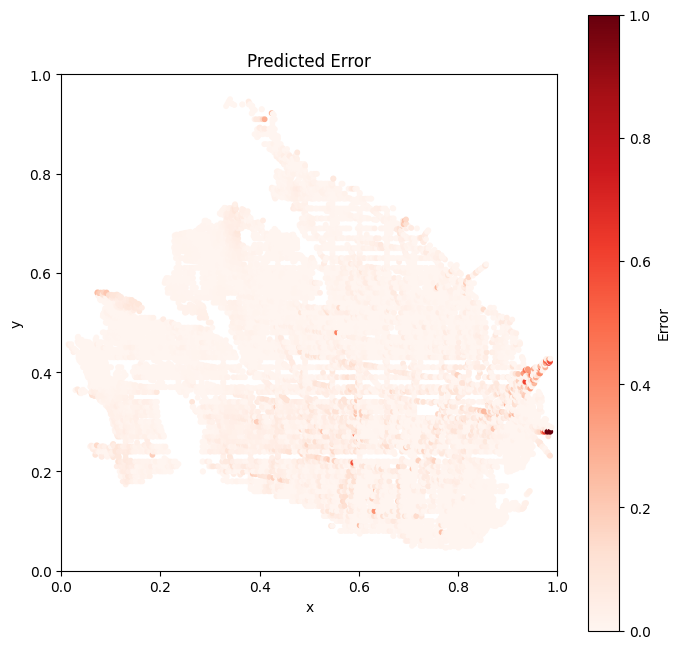

In [9]:
plt.figure(figsize = (8, 8))
plt.scatter(
    subset_x[:, 0].cpu().detach().numpy(), 
    subset_x[:, 1].cpu().detach().numpy(),
    c = me_field.cpu().detach().numpy(), 
    cmap = "Reds", 
    vmin = 0, vmax = 1,
    s = 10)
plt.colorbar(label = "Error")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Predicted Error")
plt.ylim(0, 1)
plt.xlim(0, 1)
plt.gca().set_aspect("equal")
plt.show()

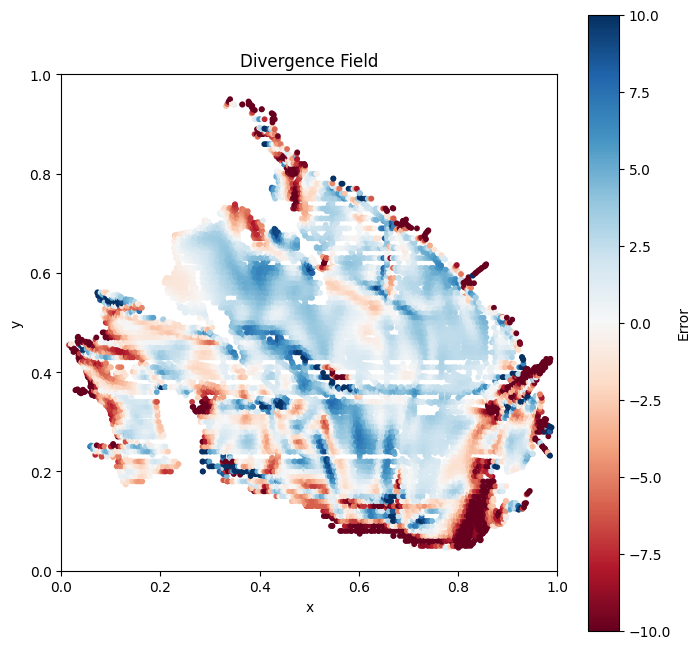

In [10]:
plt.figure(figsize = (8, 8))
plt.scatter(
    subset_x[:, 0].cpu().detach().numpy(), 
    subset_x[:, 1].cpu().detach().numpy(),
    c = div_field.cpu().detach().numpy(), 
    cmap = "RdBu", 
    vmin = -10, vmax = 10,
    s = 10)
plt.colorbar(label = "Error")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Divergence Field")
plt.ylim(0, 1)
plt.xlim(0, 1)
plt.gca().set_aspect("equal")
plt.show()

# Test points

In [11]:
from regions import ROSS_BOUNDS

x_min = ROSS_BOUNDS["x_min"]
x_max = ROSS_BOUNDS["x_max"]
y_min = ROSS_BOUNDS["y_min"]
y_max = ROSS_BOUNDS["y_max"]

In [29]:
target_grid_mask.x

<xarray.DataArray 'x' (x: 2000)> Size: 8kB
array([-599750., -599250., -598750., ...,  398750.,  399250.,  399750.],
      dtype=float32)
Coordinates:
  * x        (x) float32 8kB -5.998e+05 -5.992e+05 ... 3.992e+05 3.998e+05
Attributes:
    units:          meters
    standard_name:  projection_x_coordinate
    long_name:      X coordinate in projected system (EPSG:3031)

In [12]:
target_grid_mask = xr.load_dataset("data/target_grid_mask.nc")

X, Y = xr.broadcast(target_grid_mask.x, target_grid_mask.y)

X_long = X.values.flatten()
Y_long = Y.values.flatten()

# NOTE: Normalise to [0, 1] as model input
X_long = (X_long - x_min) / (x_max - x_min)
Y_long = (Y_long - y_min) / (y_max - y_min)

# mask_long = target_grid_mask.mask.values.flatten()

XY_long_tensor = torch.cat((torch.tensor(X_long).unsqueeze(1), torch.tensor(Y_long).unsqueeze(1)), dim = 1)
print(XY_long_tensor.shape)
print(XY_long_tensor[0:5, :])

torch.Size([4000000, 2])
tensor([[2.5000e-04, 9.9975e-01],
        [2.5000e-04, 9.9925e-01],
        [2.5000e-04, 9.9875e-01],
        [2.5000e-04, 9.9825e-01],
        [2.5000e-04, 9.9775e-01]])


# Inference

In [13]:
# breaks with 100_000 batch size
batch_size = 10_000

# Move model to device
model = model.to(device)
# Put in eval mode
model.eval()

# Move data to device (not too big for memory)
XY_long_tensor = XY_long_tensor.to(device)

# Total length
N = XY_long_tensor.shape[0]

# container for divergence batches
div_container = torch.empty((N,), dtype = torch.float32, device = "cpu")
 
for i in range(0, N, batch_size):

    # Define end index
    j = min(i + batch_size, N)

    print(f"Processing batch {i} to {j}...")

    # Subset batch
    XY_batch = XY_long_tensor[i : j , :]

    # Enable gradients
    XY_batch = XY_batch.requires_grad_(True)

    flux_predictions_batch = model(XY_batch)

    div_batch = compute_divergence_field(
        mean_pred = flux_predictions_batch, 
        x_grad = XY_batch)
    
    # For now only return divergence
    div_container[i:j] = div_batch.detach().cpu() 

    del div_batch
    del flux_predictions_batch
    torch.cuda.empty_cache()

    # for testing
    # if j == 100_000:
    #    break

Processing batch 0 to 10000...
Processing batch 10000 to 20000...
Processing batch 20000 to 30000...
Processing batch 30000 to 40000...
Processing batch 40000 to 50000...
Processing batch 50000 to 60000...
Processing batch 60000 to 70000...
Processing batch 70000 to 80000...
Processing batch 80000 to 90000...
Processing batch 90000 to 100000...
Processing batch 100000 to 110000...
Processing batch 110000 to 120000...
Processing batch 120000 to 130000...
Processing batch 130000 to 140000...
Processing batch 140000 to 150000...
Processing batch 150000 to 160000...
Processing batch 160000 to 170000...
Processing batch 170000 to 180000...
Processing batch 180000 to 190000...
Processing batch 190000 to 200000...
Processing batch 200000 to 210000...
Processing batch 210000 to 220000...
Processing batch 220000 to 230000...
Processing batch 230000 to 240000...
Processing batch 240000 to 250000...
Processing batch 250000 to 260000...
Processing batch 260000 to 270000...
Processing batch 270000 

# Reshape long input

In [15]:
# make square
div_container_square = div_container.unsqueeze(1).reshape(target_grid_mask.x.shape[0], target_grid_mask.x.shape[0])

# mask out the values outside of the boundry
# NOTE: Need to transpose mask to match dimensions
mask = torch.as_tensor(target_grid_mask["mask"].values.T, device = div_container_square.device)
div_square = div_container_square.masked_fill(mask != 1, float("nan"))

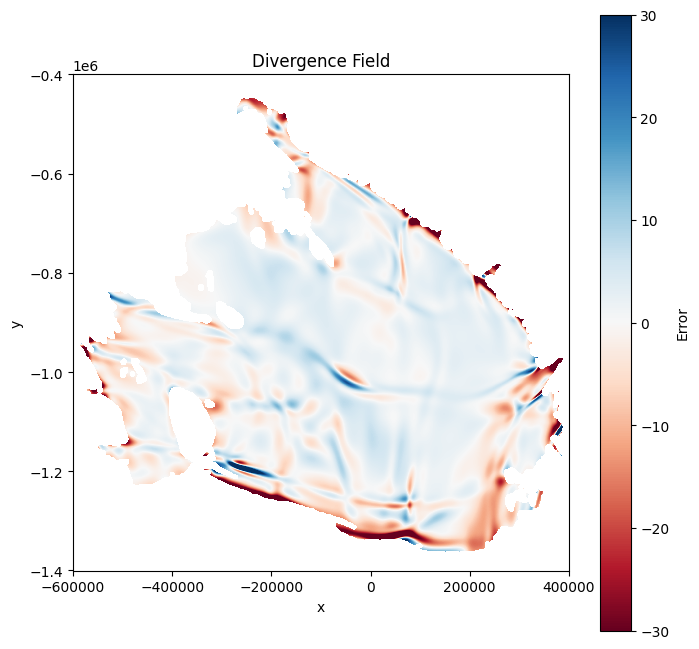

In [16]:
plt.figure(figsize = (8, 8))
plt.pcolormesh(
    # NOTE: 2D inputs
    # NOTE: Take original coords
    torch.tensor(X.values).cpu().detach().numpy(), 
    torch.tensor(Y.values).cpu().detach().numpy(),
    div_square.cpu().detach().numpy(), 
    cmap = "RdBu", 
    # equivalent to a -3, 3 mapping
    vmax = 30, 
    vmin = -30)
plt.colorbar(label = "Error")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Divergence Field")
plt.gca().set_aspect("equal")
plt.show()

# Convert units back to physical units

- **dxy = 1_000_000** because the normalised range [0, 1] presents [0, 1_000_000 m] (1000 km range) in real life.
- **flux_scale = 100_000** because we devided fluxes by 100_000 to acheve ~ 1 std i.e. var of flux in both directions.
    - The mean ice thickness of 420 meters * 438 mean ice speed yields ice flux of 183_960 for example.
- To rescale the div_field to physical units we do **div_phys = div_field * flux_scale / dxy**
- This simplifies to **dividing by 10** to get **m / year** units.

# Visualise with MODIS

In [17]:
vis_again = False

# Only rerun if needed
if vis_again :

    # Load MODIS data
    modis_ross = torch.load("data/modis/moa125_2014_hp1_v01_ross_with_grid_no_ocean.pt", weights_only = False)

    fig, ax = plt.subplots(figsize = (8, 6))

    # 1) MODIS as background (draw first)
    ax.pcolormesh(
        modis_ross[0],
        modis_ross[1], 
        modis_ross[2],
        cmap = "gray",
        # softer greys
        vmin = -30_000, 
        vmax = 30_000,
        # as less saturated background
        alpha = 0.4,
        zorder = 0,
    )

    # 2) SMB on top (draw second)
    pcm = ax.pcolormesh(
        # NOTE: 2D inputs
        # NOTE: Take original coords
        torch.tensor(X.values).cpu().detach().numpy(), 
        torch.tensor(Y.values).cpu().detach().numpy(),
        div_square.cpu().detach().numpy(), 
        vmin = -30,
        vmax = 30,
        cmap = "RdBu",
        shading = "auto",
        alpha = 1.0,
        zorder = 1,
    )

    ax.set_aspect("equal")
    ax.set_axis_off()

    fig.savefig("figures/fluxnet_div_ross.png", dpi = 300, bbox_inches = "tight", pad_inches = 0)
    plt.show()

# Generate file / overwrite variable in existing file

In [ ]:
path = "data/fluxnet_div_ross.nc"

# make field numpy and scale
# m i.e. / yr
div_np = div_square.cpu().detach().numpy() / 10.0 

# ensure (y,x) ordering on the target grid
div_da = xr.DataArray(
    div_np,
    dims = ("y", "x"),
    coords = {"x": target_grid_mask["x"], "y": target_grid_mask["y"]},
    name = "fluxnet_div",
    attrs = {
        "long_name": "Flux divergence (net) converted to metres ice-equivalent per year",
        "units": "m i.e. yr-1",
    },
).transpose("y", "x")  # no-op if already correct

if not os.path.exists(path):
    ds = div_da.to_dataset()
else:
    with xr.open_dataset(path) as _ds:
        ds = _ds.load()
    ds = ds.assign_coords(x = target_grid_mask["x"], y = target_grid_mask["y"])

ds["fluxnet_div"] = div_da

tmp = path + ".tmp"
ds.to_netcdf(tmp, mode = "w")
os.replace(tmp, path)